### Imports and Setup

In [1]:
import itertools
import math
from multiprocessing import Pool
import os
import copy

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, least_squares, leastsq
from tqdm.notebook import tqdm
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import dask
from PIL import Image
import pyproj as proj
import pygmt

from hnxwidget import HypernetxWidget
import hypernetx as hnx
import hypernetx.algorithms.hypergraph_modularity as hmod
import networkx as nx

from whale_gunshot_localization import config
import whale_gunshot_localization.utils.graph_tools as graph_tools
import whale_gunshot_localization.utils.math_tools as math_tools
from whale_gunshot_localization.utils.experimental import MultilaterationOpt

# load bathymetry map
Image.MAX_IMAGE_PIXELS = 729744000
bathym = Image.open(os.path.join(config['dataset']['data_directory'], "mikesbathym.tif"))

### Generate Synthetic Measurements

Functions to randomly generate the measurements/sources/associations and visualize the results

In [2]:
def is_in_bay(source_locs, bathym, map_origin, dx, dy):
    """
    Check if source locations are all not on land
    
    Parameters
    ----------
    source_locs : array-like[array-like]
        matrix of generated source locations'
    bathym : PIL.Image
        geotiff of the bathymetry
    map_origin : array-like of shape 1 X 2
        pixels coordinates of the origin of the bathymetry map
    dx : float
        approximate change in meters when going in the X direction
    dy : float
        approximate change in meters when going in the Y direction
    
    Returns
    -------
    : bool
        whether all source_locs are in water (True) or not (False)
    """
    
    for loc in source_locs:
        # line cutting off locations on the open-ocean side of Provincetown
        line1 = loc[0] - 0.88434446716*loc[1] < -38672.47
        # line cutting off locations on the west side of the Cape Cod Canal
        line2 = loc[0] - 0.84448322668*loc[1] > 19385.3 
        pixel = bathym.getpixel((round(map_origin[1] + loc[1]/dx), round(map_origin[0] + loc[0]/dy)))
        if pixel == 147 or line1 or line2:
            return False
    return True

def generate_random_TOSSITs(n, thresh, n_thresh):
    
    # instantiate TOSSIT locations
    TOSSIT_locations = np.zeros((n, 2))
    
    for i in range(n):
        # generate next location
        while True:
            new_loc = np.asarray([[np.random.uniform(np.min(config['TOSSIT']['TOSSIT_y']), np.max(config['TOSSIT']['TOSSIT_y'])), np.random.uniform(np.min(config['TOSSIT']['TOSSIT_x']), np.max(config['TOSSIT']['TOSSIT_x']))]])
            TOSSIT_locations[i,:] = new_loc
            if is_in_bay(new_loc, bathym, config['TOSSIT']['map_origin'], config['TOSSIT']['dx'], config['TOSSIT']['dy']) and math_tools.is_dense_locs(TOSSIT_locations[:i], thresh, n_thresh):
                break
    return TOSSIT_locations
    
def generate_measurements(num_sources, rng, var=10, num_delete=0, in_sensors=False):
    """
    Generate some synthetic measurements to test with data association/localization algoritms.
    
    Parameters
    ----------
    num_sources : int
        maximum number of sources
    var : float
        variance of Gaussian noise added to range measurements
    num_delete : int
        maximum number of measurements to hide/delete at each source
        
    Returns
    -------
    range_measurements : List[array-like]
        each sublist contains range measurements and is associated with a particular TOSSIT
    source_associations : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a source.
    TOSSIT_association : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a TOSSIT.    
    source_locs : array-like[array-like]
        matrix of generated source locations
    """ 
    
    # check inputs
    assert num_sources > 0, "number of sources must be non-negative"
    assert num_delete >= 0, "max signals to delete at each sensor must be non-negative"
    
    # get TOSSIT locations and extreme coordinate values
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    if in_sensors:
        min_x = np.min(TOSSIT_locations[:,1])
        max_x = np.max(TOSSIT_locations[:,1])
        min_y = np.min(TOSSIT_locations[:,0])
        max_y = np.max(TOSSIT_locations[:,0])
    else:
        min_x = config['scaling']['min_x']
        max_x = config['scaling']['max_x']
        min_y = config['scaling']['min_y']
        max_y = config['scaling']['max_y']
    
    # choose number of sources and generate source locations
    source_locs = np.concatenate((rng.uniform(min_y, max_y, size=(num_sources,1)), rng.uniform(min_x, max_x, size=(num_sources,1))), axis=1)
    
    # generate range measurements and log associations
    range_measurements, TOSSIT_associations, del_list, source_associations = [], [], [], []
    for t in range(TOSSIT_locations.shape[0]):
        
        # calculate range measurements from all sources to TOSSIT t, adding Gaussian noise
        r = np.abs(np.linalg.norm(source_locs - TOSSIT_locations[t,:], axis=1) + \
            rng.normal(loc=0, scale=np.sqrt(var), size=num_sources))
        range_measurements.append(r)
        
        # generate arrays for the TOSSIT associations of the measuremnts.
        TOSSIT_associations.append(np.ones((num_sources,), dtype=int) * t)
        
        # generate arrays of source associations for the measurements
        source_associations.append(np.arange(num_sources))
        
    # delete from each source
    for s in range(num_sources):
        delete_num = rng.choice(num_delete)
        if delete_num:
            distances = np.sqrt(((TOSSIT_locations - source_locs[s,:]) ** 2).sum(axis=1))
            to_delete = np.argsort(distances)[::-1][:delete_num] #rng.choice(np.arange(TOSSIT_locations.shape[0]), replace=False, size=delete_num)
            for d in to_delete:
                idx = np.argwhere(source_associations[d] == s)
                range_measurements[d] = np.delete(range_measurements[d], idx)
                source_associations[d] = np.delete(source_associations[d], idx)
                TOSSIT_associations[d] = np.delete(TOSSIT_associations[d], idx)
                
    # make sure smallest association value is 0
    bias = min([a[0] for a in source_associations if len(a)])
    if bias > 0:
        for i, a in enumerate(source_associations):
            source_associations[i] = a - bias
    return range_measurements, source_associations, TOSSIT_associations, source_locs

def visualize_collection(measurements, TOSSIT_associations, source_associations, source_locs):
    """
    Display the ground truth range measurements as lines connecting sources and sensors as well as
    the ground truth data associations which are denoted by color.
    
    Parameters
    ----------
    measurements : List[array-like]
        each sublist contains range measurements and is associated with a particular TOSSIT
    source_associations : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a source.
    TOSSIT_association : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a TOSSIT.    
    source_locs : array-like[array-like]
        matrix of generated source locations
    """
    
    # instantiate random number generator (used for color generation
    # only, so no need for custom seed)
    rng = np.random.default_rng(1111)
    
    # load TOSSIT locations
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T

    # plot sources and sensor locations
    plt.figure()
    plt.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], '^', label='sensor', markersize=12, markeredgewidth=2)
    plt.plot(source_locs[:,1], source_locs[:,0], 'o', label='source')
    
    # get unique colors for each source
    color_list = [rng.uniform(0, 1, size=3) for _ in range(source_locs.shape[0])]
    
    # get group of measurements, associated TOSSITs, and associated sources
    for i, (m, t, a) in enumerate(zip(measurements, TOSSIT_associations, source_associations)):
        # for each measurement, draw line between associated TOSSIT and source
        for j, (mm, tt, aa) in enumerate(zip(m, t, a)):
            plt.plot([TOSSIT_locations[tt,1], source_locs[aa,1]], [TOSSIT_locations[tt,0], source_locs[aa,0]], '--', color=color_list[aa])
    
    # final touches on plot
    plt.gca().invert_yaxis()
    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.title("Ideal Measurements/Associations")
    plt.legend(["sensor", "source", "source range measurement"],bbox_to_anchor=(1.05, 1.0), loc='upper left')
    plt.show()

def visualize_measurements(measurements, TOSSIT_associations, source_associations, source_locs, buffer=10000, figsize=(5,20)):
    """
    Visualize actual noisey measurements using circles centered about the TOSSIT used to make the measurement as
    well as the ground truth data associations which are donoted by colors. Plots show each source individually
    as well as all of them aggregated together.
    
    Parameters
    ----------
    measurements : List[array-like]
        each sublist contains range measurements and is associated with a particular TOSSIT
    source_associations : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a source.
    TOSSIT_association : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a TOSSIT.    
    source_locs : array-like[array-like]
        matrix of generated source locations
    buffer : float
        how much beyond the simulated bounds to display in the visualizations
    figsize : Tuple[int, int]
        figsize for each of the isolated source subplots
    """
    
    # instantiate random number generator (used for color generation
    # only, so no need for custom seed)
    rng = np.random.default_rng(1111)
    
    # load TOSSIT locations
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    min_x = config['scaling']['min_x']
    max_x = config['scaling']['max_x']
    min_y = config['scaling']['min_y']
    max_y = config['scaling']['max_y']
    max_r = config['scaling']['max_r']
    
    # figures for each source
    fig, axs = plt.subplots(source_locs.shape[0],1, figsize=figsize)
    
    # figure for all sources
    ag_fig = plt.figure()
    ag_fig.add_subplot(111)
    ag_ax = ag_fig.axes[0]
    if not isinstance(axs, np.ndarray):
        axs = np.asarray([axs])
        
    # plot associated measurements
    color_list = [rng.uniform(0, 1, size=3) for _ in range(source_locs.shape[0])]
    a_is_labeled = np.zeros((source_locs.shape[0],))
    a_ag_labeled = False
    for i, (m, t, a) in enumerate(zip(measurements, TOSSIT_associations, source_associations)):
        # plot sources and sensor locations
        for j, (mm, tt, aa) in enumerate(zip(m, t, a)):
            
            # plot range measurement
            circle1 = plt.Circle((TOSSIT_locations[tt,1], TOSSIT_locations[tt,0]), mm, color=color_list[aa], fill=False, label='range measurement' if not a_is_labeled[aa] else None)
            circle2 = plt.Circle((TOSSIT_locations[tt,1], TOSSIT_locations[tt,0]), mm, color=color_list[aa], fill=False, label='range measurement' if not a_ag_labeled else None)
            axs[aa].add_artist(circle1)
            ag_ax.add_artist(circle2)
            
            # keep track of if we have a labeled measurement
            # for each assocaition.
            if not a_is_labeled[aa]:
                a_is_labeled[aa] = 1
                a_ag_labeled = True
    
    # plot common elements among subplots
    for i, ax in enumerate(list(axs) + [ag_ax]):
        ax.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], '^', markersize=12, label='sensor', markeredgewidth=2)
        ax.set_xlabel("X [m]")
        ax.set_ylabel("Y [m]")
        ax.set_xlim([min_x-buffer, max_x+buffer])
        ax.set_ylim([min_y-buffer, max_y+buffer])
        for a in range(source_locs.shape[0]):
            ax.plot(source_locs[a,1], source_locs[a,0], 'o', color=color_list[a], label='source' if a == 0 else None)
        ax.invert_yaxis()
        if i == source_locs.shape[0]:
            ag_ax.set_title("Aggregate Measurement/Association Visualization")
        else:
            ax.set_title("Measurement/Association Visualization")
        
        # set up legend accounting for if a source has no recieved measurements
        try:
            handles, labels = ax.get_legend_handles_labels()
            order = [1,2,0]
            ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1.0), loc='upper left')
            leg = ax.get_legend()
            leg.legendHandles[1].set_color('black')
            leg.legendHandles[2].set_color('black')
        except:
            ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
            leg = ax.get_legend()
            leg.legendHandles[1].set_color('black')
    plt.show()

# Generate the measurements

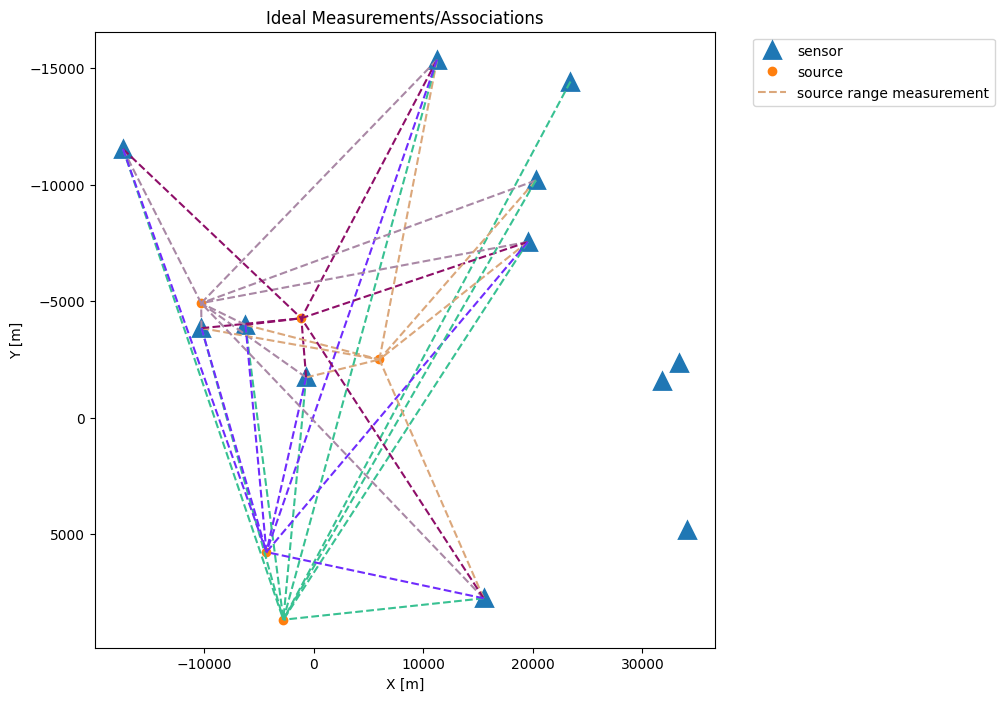

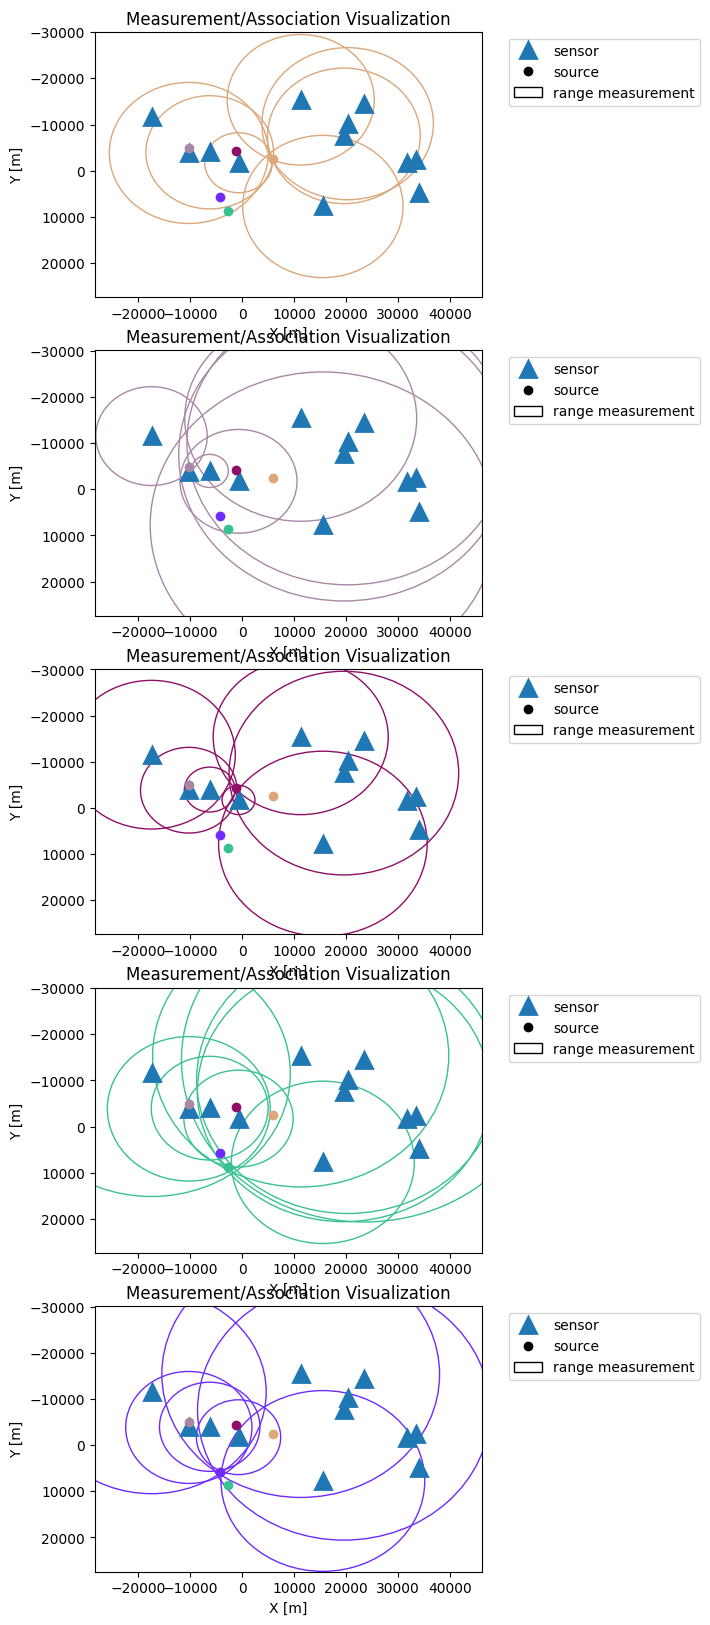

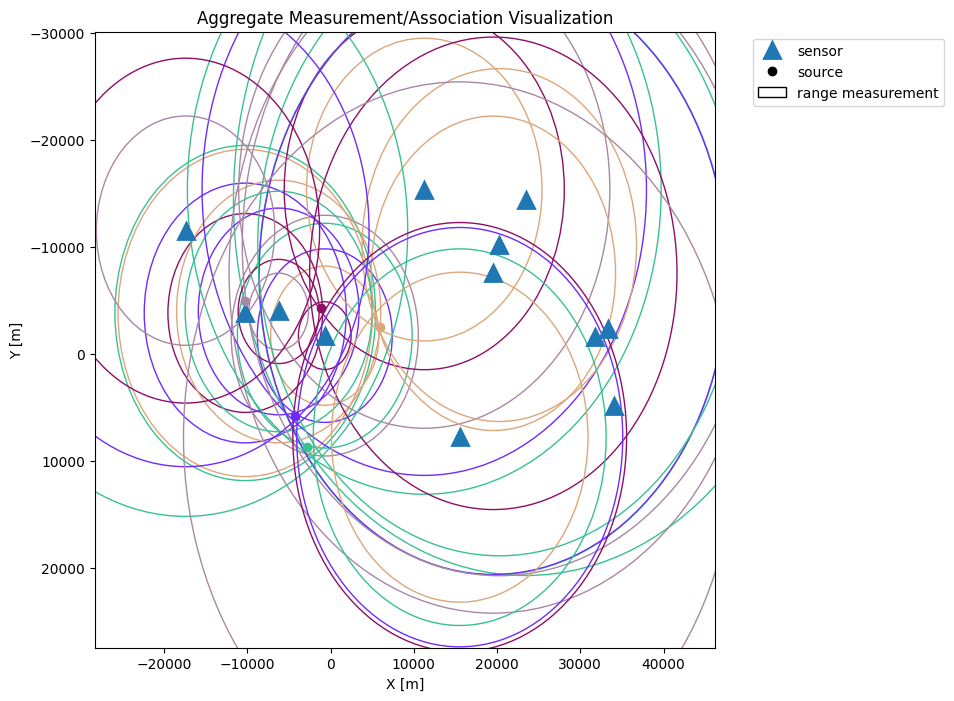

In [4]:
# generate measurements and associations
rng1 = np.random.default_rng(1265)
while True:
    measurements, source_associations, TOSSIT_associations, source_locs = generate_measurements(num_sources=5, var=1000**2, num_delete=6, rng=rng1, in_sensors=False)
    if math_tools.is_sparse_locs(source_locs, thresh=10) and is_in_bay(source_locs, bathym, config['TOSSIT']['map_origin'], config['TOSSIT']['dx'], config['TOSSIT']['dy']):
        break

# measurements = [np.asarray([17095.90450072]), np.asarray([12917.35847782]), np.asarray([9566.68791751]), np.asarray([5912.18274622]), np.asarray([5455.02918574]), np.asarray([8513.56137629]), np.asarray([12164.02174139]), np.asarray([16102.51179617]), np.asarray([15064.82778697]), np.asarray([10199.4092334]), np.asarray([10433.2142123]), np.asarray([15260.4407941])]
# source_locs = np.asarray([[-15033.64420255, 8139.99340841]])
# TOSSIT_associations = [np.asarray([0]), np.asarray([1]), np.asarray([2]), np.asarray([3]), np.asarray([4]), np.asarray([5]), np.asarray([6]), np.asarray([7]), np.asarray([8]), np.asarray([9]), np.asarray([10]), np.asarray([11])]
# source_associations = [np.asarray([0]), np.asarray([0]), np.asarray([0]), np.asarray([0]), np.asarray([0]), np.asarray([0]), np.asarray([0]), np.asarray([0]), np.asarray([0]), np.asarray([0]), np.asarray([0]), np.asarray([0])]


# visualize results
visualize_collection(measurements, TOSSIT_associations, source_associations, source_locs)
print(100*"=")
visualize_measurements(measurements, TOSSIT_associations, source_associations, source_locs)




### Graph-Based Approach

In [5]:
class Localizer:
    """
    Class to perform data association and range-based localization using 
    multiple range measurements from multiple sensors.
    
    ...
    
    Attributes
    ----------
    TOSSIT_locations : array-like of shape N X 2
        locations of the acoustic sensors or the form [y, x]
    measurements : List[array-like]
        each sublist contains range measurements associated with a particular sensor
    H : hypernetx.classes.hypergraph.Hypergraph
        hypergraph object
    k : int
        number of measurements to group when checking for measurement group consistency
    consistency_thresh : float
        threshold for distance from range to location to determine which measurements groups
        are self-consistent
    method_thresh : float in [0, 1]
        threshold to determine if approximation of H matrix from doi:10.1017/S0263574710000196
        is sufficient and determines whether to use closed-form or gradient-based localization approch
    prune : bool
        whether to prune measurement groups based on lack of range measurement intersection
    min_x : float
        minimum x coordinate used to generate simulated data for detection/range estimation network training.
        used to generate an initial guess for iterative optimization method.
    max_x : float
        maximum x coordinate used to generate simulated data for detection/range estimation network training.
        used to generate an initial guess for iterative optimization method.
    min_y : float
        minimum y coordinate used to generate simulated data for detection/range estimation network training.
        used to generate an initial guess for iterative optimization method.
    max_y : float
        maximum y coordinate used to generate simulated data for detection/range estimation network training.
        used to generate an initial guess for iterative optimization method.
    """
    
    def __init__(self, k, consistency_thresh=1000, method_thresh=0.95, prune=False, grid=False, rng=None):
        """
        Construct attributes
        
        Parameters
        ----------
        k : int
            number of measurements to group when checking for measurement group consistency
        consistency_thresh : float
            threshold for distance from range to location to determine which measurements groups
            are self-consistent
        method_thresh : float in [0, 1]
            threshold to determine if approximation of H matrix from doi:10.1017/S0263574710000196
            is sufficient and determines whether to use closed-form or gradient-based localization approch
        prune : bool
            whether to prune measurement groups based on lack of range measurement intersection
        """
        
        # load TOSSIT locations
        self.TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
        
        # initialize empty measurements and hypergraph
        self.measurements = None
        self.formatted_linear_idx = None
        self.H = None
        self._linear_measurements = None
        self._tuple_idx = None
        self._sensors = None
        self._ranges = None
        
        # uniformity constant for hypergraph
        if k > 3 and k <= self.TOSSIT_locations.shape[0]:
            self.k = k
        else:
            raise ValueError(f"k must be > 3 and < {self.TOSSIT_locations.shape[0]}.")
        
        # thresholds
        self.consistency_thresh = consistency_thresh
        self.method_thresh = method_thresh
        
        # prune sets of k measurements based on pairwise intersection check
        self.prune = prune
        
        self.memo = dict()
        
        # get bounds of considered grid
        self.min_x = config['scaling']['min_x']
        self.max_x = config['scaling']['max_x']
        self.min_y = config['scaling']['min_y']
        self.max_y = config['scaling']['max_y']

        # rng
        self.rng = rng if rng is not None else np.random.default_rng(np.random.randint(1,1000))

        if grid:
            self._make_LUT()
            self._localize = self._localize_grid
        else:
            self._localize = self._localize_opt_hybrid
    
    def _make_LUT(self):
        # precalculate TOSSIT distances for all possible gridded locations
        num_TOSSITs = self.TOSSIT_locations.shape[0]
        x = np.arange(self.min_x-10000, self.max_x+10000, 50)
        y = np.arange(self.min_y-10000, self.max_y+10000, 50)
        self.X, self.Y = np.meshgrid(x, y)
        self.LUT = np.zeros((num_TOSSITs, *self.X.shape))
        for t in range(num_TOSSITs):
            self.LUT[t,...] = np.sqrt(((self.TOSSIT_locations[t,0] - self.Y) ** 2) + ((self.TOSSIT_locations[t,1] - self.X) ** 2))
    
    def _localize_grid(self, ranges, sensors_idx):
        ranges = ranges[:,np.newaxis,np.newaxis]
        sq_err = ((self.LUT[sensors_idx,:] - ranges) ** 2).sum(axis=0)

        return np.min(sq_err), np.asarray([self.Y[sq_err == np.min(sq_err)], self.X[sq_err == np.min(sq_err)]]).squeeze()

    def _localize_opt(self, ranges, sensors_idx):
        """
        An iterative localization method based on minimizing the following cost function:
        
        (1 / N) * \sum_{i=1}^{N} (||p_{i} - p_{0}||_{2} - r_{i})^{2}.
        
        Parameters
        ----------
        ranges : array-like of shape M,
            list of range measurements from source to sensor
        sensors_idx : array-like of shape M
            list of sensor indices associated with the provided range measurements
            
        Returns
        -------
        res.fun : float
            cost function value
        res.x : array-like
            optimized location
        """
                
        # define objective function
        def obj(x):
            # calculate l2s between TOSSIT positions and predicted location
            l2 = np.sqrt((self.TOSSIT_locations[sensors_idx,0] - x[0]) ** 2 + (self.TOSSIT_locations[sensors_idx,1] - x[1]) ** 2)

            # return sum squared error between l2s and predicted ranges
            return (1 / len(ranges))*np.sum((l2.squeeze() - ranges) ** 2)

        # random initial guess
        #x0 = [0, 0] # [self.rng.uniform(self.min_y, self.max_y), self.rng.uniform(self.min_x, self.max_x)]
        x0 = [(config['scaling']['min_y'] + config['scaling']['max_y']) / 2, (config['scaling']['min_x'] + config['scaling']['max_x']) / 2]
        # x0 = [(np.min(self.TOSSIT_locations[:,0]) + np.max(self.TOSSIT_locations[:,0])) / 2, (np.min(self.TOSSIT_locations[:,1]) + np.max(self.TOSSIT_locations[:,1])) / 2 / 2]
        
        # optimize!
        res = minimize(obj, x0, method='Nelder-Mead', options={'disp': False})
        
        return res.fun, res.x
    
    def _localize_opt_hybrid(self, ranges, sensors_idx):
        """
        Hybrid localization method which choses between slower iterative method
        and the closed form method presented in doi:10.1017/S0263574710000196.
        
        Parameters
        ----------
        ranges : array-like of shape M,
            list of range measurements from source to sensor
        sensors_idx : array-like of shape M,
            list of sensor indices associated with the provided range measurements
            
        Returns
        -------
        array-like
            optimized location
        """
                
        # get sensors and save how many
        p_i = self.TOSSIT_locations.T[:,sensors_idx]
        N = p_i.shape[1]

        # calculate a, B, c, H
        a = (p_i * (p_i * p_i).sum(axis=0, keepdims=True) \
             - (ranges**2 * p_i)).sum(axis=1, keepdims=True) / N

        eye = np.dstack(N*[np.eye(2)])
        B = ((-2*np.einsum('ij,kj->jik', p_i, p_i)).sum(axis=0) \
             + (-(np.expand_dims((p_i * p_i).sum(axis=0, keepdims=True), axis=0) * eye) \
             + np.expand_dims(ranges**2, axis=0) * eye).sum(axis=2)) / N

        c = p_i.sum(axis=1, keepdims=True) / N

        H = (-2 / N)*(np.einsum('ij,kj->jik', p_i, p_i).sum(axis=0)) + (2*c @ c.T)
        
        if np.linalg.matrix_rank(H) < 2:
            cost, loc = self._localize_opt(ranges, sensors_idx)
            return cost, loc
        else:
            # check if approximation holds to make H matrix.
            # if not, use gradient-based localization
            f = a + B @ c + 2*c @ c.T @ c
        
            q = -np.linalg.inv(H) @ f

            D = B + 2*c @ c.T + (c.T @ c) * np.eye(2)
            H_hat = D - (q.T @ q)*np.eye(2)
            
            dist = math_tools.matrix_similarity(H, H_hat)
            
            if dist < self.method_thresh:
                cost, loc = self._localize_opt(ranges, sensors_idx)
                return cost, loc

            # calculate cost for closed form method
            loc = (q + c).squeeze()
            l2 = np.sqrt((self.TOSSIT_locations[sensors_idx,0] - loc[0]) ** 2 + (self.TOSSIT_locations[sensors_idx,1] - loc[1]) ** 2)
            cost = (1 / len(ranges))*np.sum((l2.squeeze() - ranges) ** 2)
            return cost, loc 
    
    def _process_sensor_group(self, s_comb, adaptive_thresh):
        
        edge_sets = []
        
        # get range measurment indices associated with specified sensors in s_comb
        ranges = [self.formatted_linear_idx[sensor_idx] for sensor_idx in s_comb]

        # get all combinations of measurement indices across the sensors as List[List]
        range_combos = map(list, itertools.product(*ranges))

        # determine which candidates are consistent
        for range_combo in range_combos:

            range_subcombos = list(map(list,itertools.combinations(range_combo, self.k-1)))
            s_subcombos = list(map(list, itertools.combinations(s_comb, self.k-1)))

            append = True
            for range_subcombo, s_subcombo in zip(range_subcombos, s_subcombos):

                # prune groups of k measurements based if any of the pairs don't intersect
                if self.prune and (not math_tools.check_intersection(self.TOSSIT_locations[s_subcombo,:], self._linear_measurements[range_subcombo])):
                    append = False
                    break

                # get trilateration cost for candidate
                key = (tuple(sorted(s_subcombo)), tuple(sorted(range_subcombo)))
                if key in self.memo.keys():
                    loc = self.memo[key]
                else:
                    _, loc = self._localize(self._linear_measurements[range_subcombo], s_subcombo)
                    self.memo[key] = loc
                # _, loc = self._localize(self._linear_measurements[range_subcombo], s_subcombo)

                r = (set(range_combo) - set(range_subcombo)).pop()
                s = (set(s_comb) - set(s_subcombo)).pop()
                if math_tools.point_circle_shortest_distance(self.TOSSIT_locations[s,:], self._linear_measurements[r], loc) > adaptive_thresh:
                    append = False
                    break

            if append:
                edge_sets.append(range_combo)
                
        return edge_sets
        
    def set_measurements(self, measurements, adaptive=False, adaptive_max=5000, threshold_delta=500):
        """
        Create a hypergraph which represents groups of k-consistent measurements.
        
        Parameters
        ----------
        measurements : List[array-like]
            each sublist contains range measurements associated with a particular sensor

        Returns
        -------
        bool
            whether associated data was found (True) or not (False)
        """
        
        # update measurements
        self.measurements = measurements

        ######################################################
        #               create formatted lists               #
        ######################################################

        # set of sensor indices with measurements
        non_empty_sensors = set()
        # list of all measurements traversed sensor-major
        self._linear_measurements = []
        # same shape as measurements but with linear indices
        self.formatted_linear_idx = [[] for _ in range(self.TOSSIT_locations.shape[0])]
        # measurement to linear index dict
        measurement_to_linear_idx = {}
        # (sensor_id, measurement_id) elements
        self._tuple_idx = []
        self._sensors = []
        self._ranges = []
        for i, m_list in enumerate(self.measurements):
            for j, m in enumerate(m_list):

                # keep track of sensors with measurements
                non_empty_sensors.add(i)

                # keep track of linear index
                linear_idx = len(self._linear_measurements)
                self.formatted_linear_idx[i].append(linear_idx)
                measurement_to_linear_idx[m] = linear_idx

                # keep linear list of measurements
                self._linear_measurements.append(m)

                self._tuple_idx.append((i, j))
                self._sensors.append(i)
                self._ranges.append(m)

        # convert linear_measurements to numpy array
        self._linear_measurements = np.asarray(self._linear_measurements)
        self._tuple_idx = np.asarray(self._tuple_idx)
        self._sensors = np.asarray(self._sensors)
        self._ranges = np.asarray(self._ranges)

        ######################################################
        #                  build hypergraph                  #
        ######################################################

        adaptive_thresh = self.consistency_thresh
        while True:
            # get all combinations of sensor indices
            sensor_combs = itertools.combinations(non_empty_sensors, self.k)

            # for each group of k sensors, get valid measurement combination
            # candidates based on trilateration errors
            scenes = {}
            edge_set_counter = 0
            
            with Pool(processes=100) as pool:
                res = pool.starmap(self._process_sensor_group, zip(sensor_combs, np.ones((math.comb(len(non_empty_sensors), self.k),)) * adaptive_thresh))
                
            for a in res:
                for b in a:
                    scenes[edge_set_counter] = b
                    edge_set_counter += 1
                        
            # save hypergraph
            if len(scenes):
                self.H = hnx.Hypergraph(scenes)
                self.memo = dict()
                return True
            elif adaptive and (not len(scenes)) and adaptive_thresh < adaptive_max:
                adaptive_thresh += threshold_delta
                continue
            else:
                self.memo = dict()
                return False

    
    def reset(self):
        self.measurements = None
        self.formatted_linear_idx = None
        self.H = None
        self._linear_measurements = None
        self._tuple_idx = None
        self._sensors = None
        self._ranges = None

    def _last_step(self, associations):
        
        assert self.measurements, "measurements have not been set"

        for a_idx in range(len(associations)):
            for m in self.formatted_linear_idx:
                
                # set of measurements which must be disjoint
                mask = set(m)

                # intersect mask with associations to find
                # where more than one member is present
                intersection = mask.intersection(associations[a_idx])

                # figure out which member of intersection
                # is the best fit based on localization
                if len(intersection) > 1:
                    max_err = float('inf')
                    best_assoc = None
                    for i in itertools.combinations(intersection, len(intersection) - 1):

                        # take away all but one measurement from the sensor measurements
                        popped_a = associations[a_idx] - set(i)

                        # get sensor indices and ranges
                        sensors = self._sensors[list(popped_a)]
                        ranges = self._ranges[list(popped_a)]
                        
                        # calculate localization cost and update best
                        cost, _ = self._localize(ranges, sensors)
                        if cost < max_err:
                            max_err = cost
                            best_assoc = popped_a
                    
                    # update association
                    associations[a_idx] = best_assoc

        return [assoc for assoc in associations if len(assoc) >= 3]

    def associate_and_localize(self, method='clique'):
        """
        Using the hypergraph constructed in self.set_measurements, perform data association
        and localization.
        
        Parameters
        ----------
        method : string
            can be either 'clique' (doesn't really work right now) or 'partition'

        Returns
        -------
        associations : List[List] if method is 'clique, List[Set] if method is 'partition'
            resulting data associations where grouped numbers represent the linear measurement
            index, traversing self.measurements in sensor-major order
        locs : array-like of shape N X 2
            predicted locations of each association set in corresponding order
        """
        
        # make sure we've set measurements
        assert self.measurements, "measurements have not been set"
        
        if method == 'clique':
            associations = []
            for h in self.H.connected_component_subgraphs():
                for clique in nx.find_cliques_recursive(h):
                    if len(clique) >= 3:
                        associations.append(clique)
        elif method == 'partition':
            HG = hmod.precompute_attributes(self.H)
            associations = hmod.kumar(HG)
            associations = self._last_step(associations)
        else:
            raise ValueError("Method must be either 'clique' or 'partition'")

        locs = []
        for a in associations:
            a = list(a)
            sensors = [self._tuple_idx[idx][0] for idx in a]
            ranges = self._linear_measurements[a]
            _, loc = self._localize(ranges, sensors)
            locs.append(loc)
        locs = np.asarray(locs)
        
        return associations, locs

In [54]:
# rng for consistency
l = Localizer(k=4, consistency_thresh=10, prune=False, method_thresh=float('inf'), grid=False)

new localizer

In [5]:
class MultilaterationBase:
    """
    Base class for multilateration algorithms.

    ...

    Attributes
    ----------
    TOSSIT_locations : array-like of shape N X 2
        locations of the acoustic sensors or the form [y, x]
    min_x : float
        minimum x coordinate used to generate simulated data for detection/range estimation network training.
        used to generate an initial guess for iterative optimization method.
    max_x : float
        maximum x coordinate used to generate simulated data for detection/range estimation network training.
        used to generate an initial guess for iterative optimization method.
    min_y : float
        minimum y coordinate used to generate simulated data for detection/range estimation network training.
        used to generate an initial guess for iterative optimization method.
    max_y : float
        maximum y coordinate used to generate simulated data for detection/range estimation network training.
        used to generate an initial guess for iterative optimization method.
    """

    def __init__(self):
        pass
    
    def set_map(self, geo_params):
        """
        To make sure we inherit the necessary geographic
        parameters and set them as attributes.

        Parameters
        ----------
        geo_params : dict
            dictionary containing geographic parameters required for
            any multilateration algorithm
        """
        
        # make sure we can inherit necessary attributes
        # from localizer object
        required = ["TOSSIT_locations", "min_x", "max_x", "min_y", "max_y"]
        assert all(param in geo_params.keys() for param in required)
        
        # set attributes
        for kv in geo_params.items():
            setattr(self, kv[0], kv[1])

class MultilaterationOpt(MultilaterationBase):
    """
    A least squares approach to multilateration

    ...

    Attributes
    ----------
    rng : numpy.random._generator.Generator
        optional RNG object
    method_thresh : float in [0, 1]
        threshold to determine if approximation of H matrix from doi:10.1017/S0263574710000196
        is sufficient and determines whether to use closed-form or gradient-based localization approch
    """

    def __init__(self, method_thresh=0.95, rng=None):
        """
        Construct attributes.

        Parameters
        ----------
        rng : numpy.random._generator.Generator
            optional RNG object
        method_thresh : float in [0, 1]
            threshold to determine if approximation of H matrix from doi:10.1017/S0263574710000196
            is sufficient and determines whether to use closed-form or gradient-based localization approch
        """

        # threshold used to decide if we can use the closed form approximation
        self.method_thresh = method_thresh

        # rng
        self.rng = rng if rng is not None else np.random.default_rng(np.random.randint(1,1000))
    
    def _opt(self, ranges, sensors_idx):
        """
        An iterative localization method based on minimizing the following cost function:
        
        (1 / N) * \sum_{i=1}^{N} (||p_{i} - p_{0}||_{2} - r_{i})^{2}.
        
        Parameters
        ----------
        ranges : array-like of shape M,
            list of range measurements from source to sensor
        sensors_idx : array-like of shape M
            list of sensor indices associated with the provided range measurements
            
        Returns
        -------
        res.fun : float
            cost function value
        res.x : array-like
            optimized location
        """

        # define objective function
        def obj(x):
            # calculate l2s between TOSSIT positions and predicted location
            l2 = np.sqrt((self.TOSSIT_locations[sensors_idx,0] - x[0]) ** 2 + (self.TOSSIT_locations[sensors_idx,1] - x[1]) ** 2)

            # return sum squared error between l2s and predicted ranges
            # return (1 / len(ranges))*np.sum((l2.squeeze() - ranges.squeeze()) ** 2)
            return l2.squeeze() - ranges.squeeze()


        # random initial guess
        # x0 = [self.rng.uniform(self.min_y, self.max_y), self.rng.uniform(self.min_x, self.max_x)]
        # x0 = [0, 0] # [self.rng.uniform(-10000, 10000), self.rng.uniform(-10000, 10000)]
        # x0 = [(config['scaling']['min_y'] + config['scaling']['max_y']) / 2, (config['scaling']['min_x'] + config['scaling']['max_x']) / 2]
        x0 = [(np.min(self.TOSSIT_locations[:,0]) + np.max(self.TOSSIT_locations[:,0])) / 2, (np.min(self.TOSSIT_locations[:,1]) + np.max(self.TOSSIT_locations[:,1])) / 2 / 2]
        # x0 = [-10000, -5000]
        # optimize!
        #res = minimize(obj, x0, method='Nelder-Mead', options={'disp': False})
        res = least_squares(obj, x0)
        # res = leastsq(obj, x0, full_output=True)
        
        return res.cost, res.x
        # return x, infodict.fvec
    
    def localize(self, ranges, sensors_idx):
        """
        Hybrid localization method which choses between slower iterative method
        and the closed form method presented in doi:10.1017/S0263574710000196.
        
        Parameters
        ----------
        ranges : array-like of shape M,
            list of range measurements from source to sensor
        sensors_idx : array-like of shape M,
            list of sensor indices associated with the provided range measurements
            
        Returns
        -------
        array-like
            optimized location
        """
                
        # get sensors and save how many
        p_i = self.TOSSIT_locations.T[:,sensors_idx]
        N = p_i.shape[1]

        # calculate a, B, c, H
        a = (p_i * (p_i * p_i).sum(axis=0, keepdims=True) \
             - (ranges**2 * p_i)).sum(axis=1, keepdims=True) / N

        eye = np.dstack(N*[np.eye(2)])
        B = ((-2*np.einsum('ij,kj->jik', p_i, p_i)).sum(axis=0) \
             + (-(np.expand_dims((p_i * p_i).sum(axis=0, keepdims=True), axis=0) * eye) \
             + np.expand_dims(ranges**2, axis=0) * eye).sum(axis=2)) / N

        c = p_i.sum(axis=1, keepdims=True) / N

        H = (-2 / N)*(np.einsum('ij,kj->jik', p_i, p_i).sum(axis=0)) + (2*c @ c.T)
        
        f = a + B @ c + 2*c @ c.T @ c

        if np.linalg.matrix_rank(H) < 2:
            try:
                # calculate H'
                Hp = H[0,0] - H[1,0]

                # calculate h'
                hp = -(H[0,1] - H[1,1])

                # calculate f'
                fp = -(f[0,0] - f[1,0])

                # calculate H^{f}_{k}
                Hfk = fp

                # calculate H^{h}_{k}
                Hhk = hp

                # calculate q^{T}q
                qTq = (-(1 / N)*(p_i*p_i).sum().squeeze() + (1 / N)*(ranges ** 2).sum().squeeze() + (c.T @ c).squeeze())

                # calculate qn1 and qn2
                aa = (Hhk ** 2) + (Hp ** 2)
                bb = (2*Hfk*Hhk)
                cc = ((Hfk ** 2) - ((Hp ** 2)*qTq))
                qn1 = (-bb + np.sqrt((bb ** 2) - 4*aa*cc)) / (2*aa)
                qn2 = (-bb - np.sqrt((bb ** 2) - 4*aa*cc)) / (2*aa)
                qn = np.asarray([[qn1, qn2]])

                # calculate qk
                qk = (Hfk / Hp) + ((Hhk / Hp)*qn)

                # calculate q
                q = np.concatenate((qk, qn), axis=0)

                loc = (q + c)
                min_idx = 0
                min_cost = float('inf')
                for i in range(2):
                    l2 = np.sqrt((self.TOSSIT_locations[sensors_idx,0] - loc[0,i]) ** 2 + (self.TOSSIT_locations[sensors_idx,1] - loc[1,i]) ** 2)
                    cost = 0.5*np.sum((l2.squeeze() - ranges) ** 2)

                    if cost < min_cost:
                        min_cost = cost
                        min_idx = i

                q = q[:,[min_idx]]
            except:
                cost, loc = self._opt(ranges, sensors_idx)
                return cost, loc
                
        else:
            q = -np.linalg.inv(H) @ f
            loc = (q + c).squeeze()
            l2 = np.sqrt((self.TOSSIT_locations[sensors_idx,0] - loc[0]) ** 2 + (self.TOSSIT_locations[sensors_idx,1] - loc[1]) ** 2)
            min_cost = 0.5*np.sum((l2.squeeze() - ranges) ** 2)
        
        D = B + 2*c @ c.T + (c.T @ c) * np.eye(2)
        H_hat = D - (q.T @ q)*np.eye(2)

        dist = math_tools.matrix_similarity(H, H_hat)
        if dist < self.method_thresh:
            cost, loc = self._opt(ranges, sensors_idx)
            return cost, loc
        
        return min_cost, (q + c).squeeze()

class MultilaterationGrid(MultilaterationBase):
    """
    Grid-based multilateration.

    ...

    Attributes
    ----------
    rng : numpy.random._generator.Generator
        optional RNG object
    X : array-like
        X meshgrid of locations
    Y : array-like
        Y meshgrid of locations
    LUT : array-like
        look up table of ranges from each location to each TOSSIT
    """

    def __init__(self, rng=None):
        """
        Construct attributes.

        Parameters
        ----------
        rng : numpy.random._generator.Generator
            optional RNG object
        """
        
        # rng
        self.rng = rng if rng is not None else np.random.default_rng(np.random.randint(1,1000))
        
        # track when we've made LUT
        self.LUT_exists = False
    
    def _make_LUT(self):
        """
        Construct LUT of ranges from each TOSSIT
        """

        # make locations meshgrid
        num_TOSSITs = self.TOSSIT_locations.shape[0]
        x = np.arange(self.min_x+5000, self.max_x-5000, 100)
        y = np.arange(self.min_y-5000, self.max_y+5000, 100)
        self.X, self.Y = np.meshgrid(x, y)

        # create LUT
        self.LUT = np.zeros((num_TOSSITs, *self.X.shape))
        for t in range(num_TOSSITs):
            self.LUT[t,...] = np.sqrt(((self.TOSSIT_locations[t,0] - self.Y) ** 2) + ((self.TOSSIT_locations[t,1] - self.X) ** 2))
    
    def localize(self, ranges, sensors_idx):

        # check if we need to make LUT
        if not self.LUT_exists:
            self._make_LUT()
            self.LUT_exists = True

        # calculate square error of measured ranges and ranges of each location
        ranges = ranges[:,np.newaxis,np.newaxis]
        sq_err = ((self.LUT[sensors_idx,:] - ranges) ** 2).sum(axis=0)

        return np.min(sq_err), np.asarray([self.Y[sq_err == np.min(sq_err)], self.X[sq_err == np.min(sq_err)]]).squeeze()

class Localizer:
    """
    Class to perform data association and range-based localization using 
    multiple range measurements from multiple sensors.
    
    ...
    
    Attributes
    ----------
    TOSSIT_locations : array-like of shape N X 2
        locations of the acoustic sensors or the form [y, x]
    measurements : List[array-like]
        each sublist contains range measurements associated with a particular sensor
    H : hypernetx.classes.hypergraph.Hypergraph
        hypergraph object
    k : int
        number of measurements to group when checking for measurement group consistency
    consistency_thresh : float
        threshold for distance from range to location to determine which measurements groups
        are self-consistent
    prune : bool
        whether to prune measurement groups based on lack of range measurement intersection
    multilat : object
        Python object used to perform multilateration
    """
    
    def __init__(self, k, multilat, consistency_thresh=1000, dup_thresh=4000, prune=False):
        """
        Construct attributes
        
        Parameters
        ----------
        k : int
            number of measurements to group when checking for measurement group consistency
        multilat : object
            Python object used to perform multilateration
        consistency_thresh : float
            threshold for distance from range to location to determine which measurements groups
            are self-consistent
        prune : bool
            whether to prune measurement groups based on lack of range measurement intersection
        """
        
        # load TOSSIT locations
        self.TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
        
        # initialize empty measurements and hypergraph
        self.measurements = None
        self.formatted_linear_idx = None
        self.H = None
        self._linear_measurements = None
        self._tuple_idx = None
        self._sensors = None
        self._ranges = None
        
        # uniformity constant for hypergraph
        if k > 3 and k <= self.TOSSIT_locations.shape[0]:
            self.k = k
        else:
            raise ValueError(f"k must be > 3 and < {self.TOSSIT_locations.shape[0]}.")
        
        # thresholds
        self.consistency_thresh = consistency_thresh
        
        # prune sets of k measurements based on pairwise intersection check
        self.prune = prune
        
        # threshold to combine localizations
        self.dup_thresh = dup_thresh

        self.multilat = multilat
        self.multilat.set_map({
            'TOSSIT_locations' : self.TOSSIT_locations,
            'min_x' : config['scaling']['min_x'],
            'max_x' : config['scaling']['max_x'],
            'min_y' : config['scaling']['min_y'],
            'max_y' : config['scaling']['max_y'],
        })
        
    def set_measurements(self, measurements, adaptive=False, adaptive_max=5000, threshold_delta=500):
        """
        Create a hypergraph which represents groups of k-consistent measurements.
        
        Parameters
        ----------
        measurements : List[array-like]
            each sublist contains range measurements associated with a particular sensor
        adaptive : bool
            whether to increase the consistency threshold if no consistent measurements are found
        adaptive_max : float
            maximum consistency threshold to use before giving up when operating adaptively
        threshold_delta : float
            how much to increase the consistency threhold if no consistent groups are found when adaptive

        Returns
        -------
        bool
            whether associated data was found (True) or not (False)
        """
        
        # update measurements
        self.measurements = measurements

        ######################################################
        #               create formatted lists               #
        ######################################################

        # set of sensor indices with measurements
        non_empty_sensors = set()
        # list of all measurements traversed sensor-major
        self._linear_measurements = []
        # same shape as measurements but with linear indices
        self.formatted_linear_idx = [[] for _ in range(self.TOSSIT_locations.shape[0])]
        # measurement to linear index dict
        measurement_to_linear_idx = {}
        # (sensor_id, measurement_id) elements
        self._tuple_idx = []
        self._sensors = []
        self._ranges = []
        for i, m_list in enumerate(self.measurements):
            for j, m in enumerate(m_list):

                # keep track of sensors with measurements
                non_empty_sensors.add(i)

                # keep track of linear index
                linear_idx = len(self._linear_measurements)
                self.formatted_linear_idx[i].append(linear_idx)
                measurement_to_linear_idx[m] = linear_idx

                # keep linear list of measurements
                self._linear_measurements.append(m)

                self._tuple_idx.append((i, j))
                self._sensors.append(i)
                self._ranges.append(m)

        # convert linear_measurements to numpy array
        self._linear_measurements = np.asarray(self._linear_measurements)
        self._tuple_idx = np.asarray(self._tuple_idx)
        self._sensors = np.asarray(self._sensors)
        self._ranges = np.asarray(self._ranges)

        ######################################################
        #                  build hypergraph                  #
        ######################################################

        # memoize localization
        memo = dict()

        adaptive_thresh = self.consistency_thresh
        while True:
            # get all combinations of sensor indices
            sensor_combs = itertools.combinations(non_empty_sensors, self.k)

            # for each group of k sensors, get valid measurement combination
            # candidates based on trilateration errors
            scenes = {}
            edge_set_counter = 0
            for s_comb in sensor_combs:

                # get range measurment indices associated with specified sensors in s_comb
                ranges = [self.formatted_linear_idx[sensor_idx] for sensor_idx in s_comb]

                # get all combinations of measurement indices across the sensors as List[List]
                range_combos = map(list, itertools.product(*ranges))

                # determine which candidates are consistent
                for range_combo in range_combos:

                    range_subcombos = list(map(list,itertools.combinations(range_combo, self.k-1)))
                    s_subcombos = list(map(list, itertools.combinations(s_comb, self.k-1)))

                    append = True
                    for range_subcombo, s_subcombo in zip(range_subcombos, s_subcombos):
                        # prune groups of k measurements based if any of the pairs don't intersect
                        if self.prune and (not math_tools.check_intersection(self.TOSSIT_locations[s_subcombo,:], self._linear_measurements[range_subcombo])):
                            append = False
                            break 

                        # get trilateration cost for candidate
                        key = (tuple(sorted(s_subcombo)), tuple(sorted(range_subcombo)))
                        if key in memo.keys():
                            loc = memo[key]
                        else:
                            _, loc = self.multilat.localize(self._linear_measurements[range_subcombo], s_subcombo)
                            memo[key] = loc
                            
                        r = (set(range_combo) - set(range_subcombo)).pop()
                        s = (set(s_comb) - set(s_subcombo)).pop()
                        if math_tools.point_circle_shortest_distance(self.TOSSIT_locations[s,:], self._linear_measurements[r], loc) > adaptive_thresh:
                            append = False
                            break

                    if append:
                        scenes[edge_set_counter] = range_combo
                        edge_set_counter += 1
            
            # save hypergraph
            if len(scenes):
                self.H = hnx.Hypergraph(scenes)
                return True
            elif adaptive and (not len(scenes)) and adaptive_thresh < adaptive_max:
                adaptive_thresh += threshold_delta
                continue
            else:
                return False

    def reset(self):
        """
        Reset object between different data
        """
        
        self.measurements = None
        self.formatted_linear_idx = None
        self.H = None
        self._linear_measurements = None
        self._tuple_idx = None
        self._sensors = None
        self._ranges = None
    
    def _eliminate_dups(self, locs, assocs, thresh=2000):
        assocs = np.asarray(assocs, dtype=object)
        locs_no_dups = []
        assocs_no_dups = []
        while True:
            idx = np.arange(len(locs))
                        
            if len(locs) == 1:
                locs_no_dups.append(locs[0])
                assocs_no_dups.append(assocs[0])
                break
            
            if len(locs) == 0:
                break

            # remove the ith location estimate
            sub_idx = np.delete(idx, 0, axis=0)

            # get distance form ith location estimate to the rest
            dists = np.sqrt(((locs[sub_idx] - locs[0]) ** 2).sum(axis=1))

            if (dists <= thresh).sum():
                to_del = [0] + list(sub_idx[dists <= thresh])
                
                new_association = set.union(*assocs[to_del])
                
                # get sensor indices and ranges
                sensors = self._sensors[list(new_association)]
                ranges = self._ranges[list(new_association)]
                
                _, loc = self.multilat.localize(ranges, sensors)
                locs_no_dups.append(loc)
                assocs_no_dups.append(new_association)

                locs = np.delete(locs, to_del, axis=0)
                assocs = np.delete(assocs, to_del, axis=0)
            else:
                locs_no_dups.append(locs[0])
                assocs_no_dups.append(assocs[0])
                locs = np.delete(locs, 0, axis=0)
                assocs = np.delete(assocs, 0, axis=0)
        
        return assocs_no_dups, np.asarray(locs_no_dups)
    
    def _last_step(self, locs, associations):
        """
        Greedy algorithm to make sure each association has only one measurement from any given sensor.
        It finds the lowest cost member of each association among multiple measurements from a given sensor
        if there are any.

        Parameters
        ----------
        assocaitions : List[Set]
            Input associations
        
        Returns
        -------
        List[Set]
            Final associations
        """

        assert self.measurements, "measurements have not been set"
        
        
        for a_idx in range(len(associations)):
            formatted_linear_idx_cpy = copy.deepcopy(self.formatted_linear_idx)
            np.random.shuffle(formatted_linear_idx_cpy)
            for m in formatted_linear_idx_cpy:
                
                # set of measurements which must be disjoint
                mask = set(m)

                # intersect mask with associations to find
                # where more than one member is present
                intersection = mask.intersection(associations[a_idx])

                # figure out which member of intersection
                # is the best fit based on localization
                if len(intersection) > 1:
                    max_err = float('inf')
                    best_assoc = None
                    best_loc = None
                    for i in itertools.combinations(intersection, len(intersection) - 1):

                        # take away all but one measurement from the sensor measurements
                        popped_a = associations[a_idx] - set(i)

                        # get sensor indices and ranges
                        sensors = self._sensors[list(popped_a)]
                        ranges = self._ranges[list(popped_a)]
                        
                        # calculate localization cost and update best
                        cost, loc = self.multilat.localize(ranges, sensors)

                        if cost < max_err:
                            max_err = cost
                            best_assoc = popped_a
                            best_loc = loc
                    
                    # update association
                    associations[a_idx] = best_assoc
                    locs[a_idx] = best_loc         

        return [assoc for assoc in associations if len(assoc) >= 3], np.asarray([loc for i, loc in enumerate(locs) if len(associations[i]) >= 3])

    def associate_and_localize(self, method='clique', reduce_dups=True, last_step=True):
        """
        Using the hypergraph constructed in self.set_measurements, perform data association
        and localization.
        
        Parameters
        ----------
        method : string
            can be either 'clique' (doesn't really work right now) or 'partition'

        Returns
        -------
        associations : List[List] if method is 'clique, List[Set] if method is 'partition'
            resulting data associations where grouped numbers represent the linear measurement
            index, traversing self.measurements in sensor-major order
        locs : array-like of shape N X 2
            predicted locations of each association set in corresponding order
        """
        
        # make sure we've set measurements
        assert self.measurements, "measurements have not been set"
        
        if method == 'clique':
            associations = []
            for h in self.H.connected_component_subgraphs():
                for clique in nx.find_cliques_recursive(h):
                    if len(clique) >= 3:
                        associations.append(clique)
        elif method == 'partition':
            HG = hmod.precompute_attributes(self.H)
            associations = hmod.kumar(HG)
        else:
            raise ValueError("Method must be either 'clique' or 'partition'")

        locs = []
        for a in associations:
            a = list(a)
            sensors = [self._tuple_idx[idx][0] for idx in a]
            ranges = self._linear_measurements[a]
            _, loc = self.multilat.localize(ranges, sensors)
            locs.append(loc)
        locs = np.asarray(locs)
        
        if reduce_dups:
            associations, locs = self._eliminate_dups(locs, associations, thresh=self.dup_thresh)
        if last_step:
            associations, locs = self._last_step(locs, associations)
        return associations, locs

In [12]:
# rng for consisten
l = Localizer(k=4, multilat=MultilaterationOpt(method_thresh=float('inf')), consistency_thresh=1000, dup_thresh=3000, prune=False)

In [13]:
%%time
l.set_measurements(measurements, adaptive=False)
# HypernetxWidget(l.H)

CPU times: user 13.5 s, sys: 17.6 s, total: 31.1 s
Wall time: 9.73 s


True

In [14]:
assoc, locs_est = l.associate_and_localize(method='partition', reduce_dups=False, last_step=True)

In [15]:
def get_bearing(x_ends, y_ends):
    return math.atan2(y_ends[1] - y_ends[0], x_ends[1] - x_ends[0]) * (180 / math.pi)

def bearing_error(bearing1, bearing2):
    theta = np.abs(bearing1 - bearing2)
    if theta > 180:
        theta = 360 - theta
    return theta

def plot_localization(source_locs, locs_est=None, title='', bathym=None, buffer=6000, trajectory=False): 
    
    # load constants
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    min_x = config['scaling']['min_x']
    max_x = config['scaling']['max_x']
    min_y = config['scaling']['min_y']
    max_y = config['scaling']['max_y']
    map_origin = config['TOSSIT']['map_origin']
    dy = config['TOSSIT']['dy']
    dx = config['TOSSIT']['dx']
    
    if bathym:
        # crop bathymetry appropriately 
        bathym = bathym.crop((round(map_origin[1] + (min_x/dx) - (buffer/dx)), 
                              round(map_origin[0] + (min_y/dy) - (buffer/dy)), 
                              round(map_origin[1] + (max_x/dx) + (buffer/dx)), 
                              round(map_origin[0] + (max_y/dy) + (buffer/dy))))
    
    plt.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], '^', markersize=12, label='sensor', markeredgewidth=2)
    plt.plot(source_locs[:,1], source_locs[:,0], 'o', label='ground truth')
    if trajectory:
        pass
        plt.plot([source_locs[0,1], source_locs[-1,1]], [source_locs[0,0], source_locs[-1,0]], label='GT')
    if locs_est is not None:
        plt.plot(locs_est[:,1], locs_est[:,0], 'x', label='estimate', markeredgewidth=2)
        if trajectory:
            # make point vectors
            x = locs_est[:, [1]]
            y = -locs_est[:,0]
            huber = make_pipeline(StandardScaler(), HuberRegressor())
            huber.fit(x, y)
            h = huber.named_steps["huberregressor"]
            
            x_ends = np.asarray([[np.min(x)], [np.max(x)]])
            y_ends = h.predict(x_ends)
            
            plt.plot(x_ends, -1*y_ends, label='fit')
#             pcr = make_pipeline(StandardScaler(), PCA(n_components=1), LinearRegression())
#             pcr.fit(x, y)
#             pca = pcr.named_steps["pca"]
    

#             x_ends = np.asarray([[np.min(x)], [np.max(x)]])
#             y_ends = pcr.predict(x_ends)

            
#             plt.plot(x_ends, -1*y_ends, label='fit')


            theta_hat = get_bearing(x_ends.squeeze(), y_ends)
            idx1 = np.argmin(source_locs[:,1])
            idx2 = np.argmax(source_locs[:,1])
            theta = get_bearing([source_locs[idx1,1], source_locs[idx2,1]], [-source_locs[idx1,0], -source_locs[idx2,0]])
            print(bearing_error(theta, theta_hat))
            print(theta, theta_hat)
            
    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.xlim([min_x-buffer, max_x+buffer])
    plt.ylim([min_y-buffer, max_y+buffer])
    plt.gca().invert_yaxis()
    if bathym:
        implot = plt.imshow(bathym, extent=(min_x - buffer, max_x + buffer, max_y + buffer, min_y - buffer))
    plt.legend()
    if len(title):
        plt.title(title)
    plt.show()

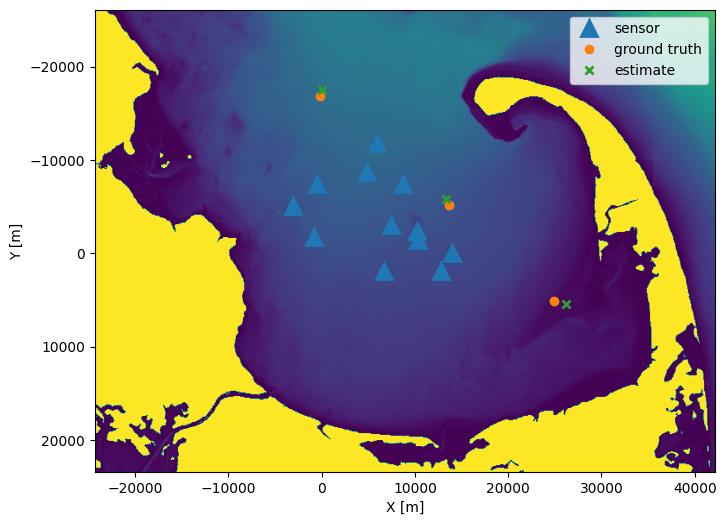

In [10]:
plot_localization(source_locs, locs_est, bathym=bathym)

In [16]:
def get_bearing(x_ends, y_ends):
    return math.atan2(y_ends[1] - y_ends[0], x_ends[1] - x_ends[0]) * (180 / math.pi)

def bearing_error(bearing1, bearing2):
    theta = np.abs(bearing1 - bearing2)
    if theta > 180:
        theta = 360 - theta
    return theta

def plot_localization(source_locs, locs_est=None, title='', bathym=None, buffer=6000, trajectory=False): 

    # load constants
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    min_x = config['scaling']['min_x']
    max_x = config['scaling']['max_x']
    min_y = config['scaling']['min_y']
    max_y = config['scaling']['max_y']
    
    # define projection object
    pargs = proj.Proj(proj="aeqd", lat_0=41.9108, lon_0=-70.4292, datum="WGS84", units="m")
    
    # get lon/lat bounds for the map
    lon, lat = pargs([min_x-buffer, max_x+buffer], [min_y-buffer, max_y+buffer], inverse=True)
    region = [*lon, *lat]
    
    # convert source and sensor locs to lat/lon
    lon, lat = pargs(source_locs[:,1], -source_locs[:,0], inverse=True)
    lon_TOSSIT, lat_TOSSIT = pargs(TOSSIT_locations[:,1], -TOSSIT_locations[:,0], inverse=True)
    
    # if ests, convert to lat/lon
    if locs_est is not None:
        plon, plat = pargs(locs_est[:,1], -locs_est[:,0], inverse=True)
    
    fig = pygmt.Figure()
    fig.basemap(region=region, projection="M15c", frame=True)
    fig.coast(land="black", water="skyblue")
    fig.plot(x=lon_TOSSIT, y=lat_TOSSIT, style="t0.3c", fill="green", pen="black", label="sensors")
    fig.plot(x=lon, y=lat, style="c0.3c", fill="white", pen="black", label="GT")
    
    if locs_est is not None:
        # plot lat/lons of estimates
        fig.plot(x=plon, y=plat, style="x0.3c", fill="red", pen="2p,red", label="estimates")
    
        if trajectory:
            # perform PCA regression
            x = locs_est[:, [1]]
            y = -locs_est[:,0]
            pcr = make_pipeline(StandardScaler(), PCA(n_components=1), LinearRegression())
            pcr.fit(x, y)
            pca = pcr.named_steps["pca"]
            x_ends = np.asarray([[np.min(x)], [np.max(x)]])
            y_ends = pcr.predict(x_ends)
            
            # convert estimate line ends to lat/lon
            lons_est, lats_est = pargs(x_ends.squeeze(), y_ends.squeeze(), inverse=True)
            
            # plot PCA regression of estimates
            fig.plot(x=lons_est, y=lats_est, pen="1p,purple", label='trajectory fit')
            
    if trajectory:
        fig.plot(x=[lon[0], lon[-1]], y=[lat[0], lat[-1]], pen="1p,orange", label="true trajectory")
    
    fig.legend()
    fig.show()    

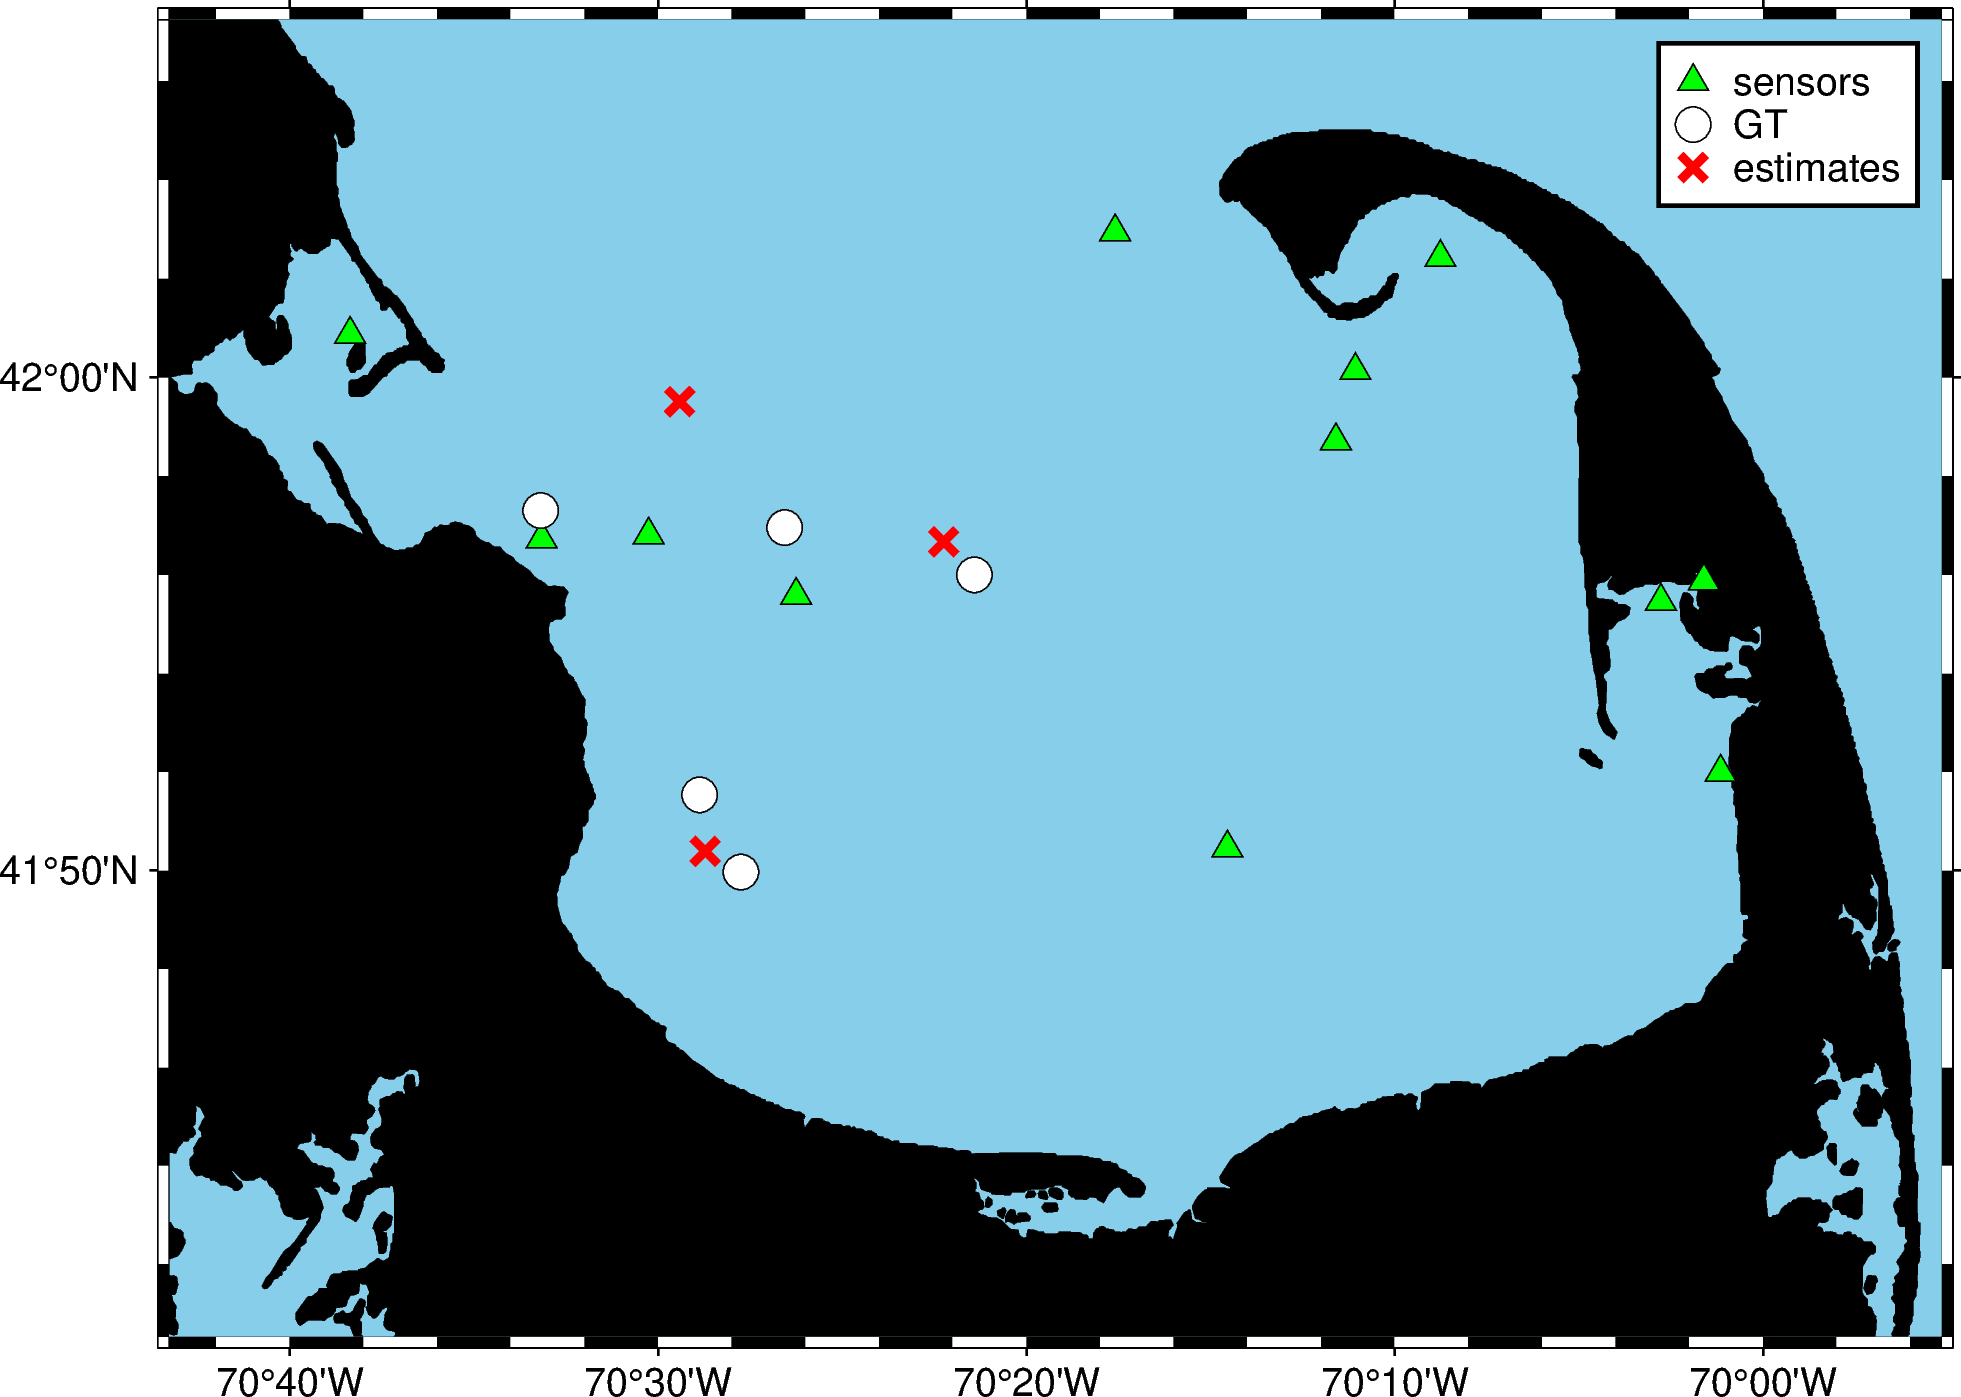

In [17]:
plot_localization(source_locs, locs_est, bathym=bathym)

In [29]:
# calculate errors in the best alignment of source locations and their estimates
num_ests = locs_est.shape[0]
source_loc_combs = np.asarray(list(map(list, itertools.permutations(source_locs))))
source_loc_idx_combs = np.asarray(list(map(list, itertools.permutations(np.arange(source_locs.shape[0])))))
errors_matrix = np.sqrt(((source_loc_combs[:,:num_ests,:] - locs_est[np.newaxis,:,:]) ** 2).sum(axis=2)).sum(axis=1)
res = np.sqrt(((source_loc_combs[np.argmin(errors_matrix),:num_ests,:] - locs_est[np.newaxis,:,:]) ** 2).sum(axis=2)).flatten()

# prepare localizer object
measurements_flat = np.concatenate(measurements)
assoc_flat = np.concatenate(source_associations)
TOSSIT_flat = np.concatenate(TOSSIT_associations)
localizer = MultilaterationOpt(method_thresh=float('inf'))
TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
localizer.set_map({
    'TOSSIT_locations' : TOSSIT_locations,
    'min_x' : config['scaling']['min_x'],
    'max_x' : config['scaling']['max_x'],
    'min_y' : config['scaling']['min_y'],
    'max_y' : config['scaling']['max_y'],
})

# calculate least squares errors with known associations
detected_sources = source_loc_idx_combs[np.argmin(errors_matrix)][:num_ests]
best_locs = []
print(assoc_flat)
print(measurements_flat)
print(TOSSIT_flat)
print(source_locs[0])
for sidx in detected_sources:
    idx = np.where(assoc_flat == sidx)[0]
    _, loc = localizer.localize(measurements_flat[idx], TOSSIT_flat[idx])
    best_locs.append(loc)
    print(best_locs)
best_locs = np.asarray(best_locs)
best_res = np.sqrt(((best_locs - source_locs[detected_sources]) ** 2).sum(axis=1))

print("Our Errors: ", res)
print("LS Known Associations Errors: ", best_res)

[0 0 0 0 0 0]
[10080.19279035 15069.58477993 13639.99440837 17557.97052437
 15660.29624094 10928.15123708]
[ 0  1  8  9 10 11]
[10036.9127353    933.09669094]
[array([10036.9127353 ,   933.09669094])]
Our Errors:  [1.77074321e-11]
LS Known Associations Errors:  [1.3037536e-10]


### Predicting Trajectories

In [48]:
def generate_trajectory(num_points, beam_width=20, measurement_stats=(0, 500000), timing_stats=(1, 0.5), repetition_time=0.5, num_repetitions=1, whale_speed=1.3, chunk_size=2, max_channel_offset=40, num_delete=0, rng=None):
    
    # check inputs
    assert num_points > 0, "number of sources must be non-negative"

    if rng is None:
        rng = np.random
    
    # convert whale speed to m / second
    whale_speed *= (1000 / 60)
    # convert timing_stats to seconds
    timing_stats = tuple([i*60 for i in timing_stats])
    # convert chunk size to seconds
    chunk_size *= 60
    
    # get TOSSIT locations and extreme coordinate values
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    min_x = config['scaling']['min_x']
    max_x = config['scaling']['max_x']
    min_y = config['scaling']['min_y']
    max_y = config['scaling']['max_y']
    
    # choose number of sources and generate source locations
    source_locs = np.concatenate((rng.uniform(min_y, max_y, size=(1,1)), rng.uniform(min_x, max_x, size=(1,1))), axis=1)
    time_stamps = np.arange(0, num_repetitions * repetition_time, repetition_time)
    heading = rng.uniform(0, 359, size=1)
    
    curr_loc = source_locs[[0]]
    measurements = [np.asarray([]) for _ in range(TOSSIT_locations.shape[0])]
    source_associations = [np.asarray([]) for _ in range(TOSSIT_locations.shape[0])]
    TOSSIT_associations = [np.asarray([]) for _ in range(TOSSIT_locations.shape[0])]
    s_count = 0
    while True:
        
        # get measurements
        for t in range(TOSSIT_locations.shape[0]):
            # calculate range measurements from all sources to TOSSIT t, adding Gaussian noise
            r = np.linalg.norm(curr_loc - TOSSIT_locations[t,:], axis=1) + \
                rng.normal(loc=measurement_stats[0], scale=np.sqrt(measurement_stats[1]), size=num_repetitions)
            measurements[t] = np.append(measurements[t], r)
            source_associations[t] = np.append(source_associations[t], s_count)
            TOSSIT_associations[t] = np.append(TOSSIT_associations[t], t)

        if source_locs.shape[0] == num_points:
            break
        
        # time delta to next source
        new_time_delta = rng.normal(loc=timing_stats[0], scale=np.sqrt(timing_stats[1]))
        
        # timestamp(s) for current source location
        time_stamps = np.append(time_stamps, [time_stamps[-1] + new_time_delta + repetition_time*i for i in range(num_repetitions)])

        # calculate magnitude of transition vector
        vec_mag = whale_speed * new_time_delta
    
        # transition vector to get from current location to the next one
        transition_vector = (vec_mag * np.asarray([-np.sin(np.radians(heading)), np.cos(np.radians(heading))])).T
        
        # get new location and save
        curr_loc += transition_vector
        source_locs = np.concatenate((source_locs, curr_loc), axis=0)
        
        # get new heading
        heading += rng.uniform(-beam_width / 2, beam_width / 2)
        
        s_count += 1

    # create offset timestamps for each sensor
    time_stamps = [time_stamps] #time_stamps[np.newaxis,:]
    for t in range(1,TOSSIT_locations.shape[0]):
        offset = rng.uniform(low=0, high=max_channel_offset)
        time_stamps.append(time_stamps[0] + offset) # = np.concatenate((time_stamps, time_stamps[[0],:] + offset), axis=0)
    
    # delete from each source
    if num_delete:
        for s in range(num_points):
            distances = np.sqrt(((TOSSIT_locations - source_locs[s,:]) ** 2).sum(axis=1))
            to_delete = np.argsort(distances)[::-1][:TOSSIT_locations.shape[0] - num_delete]
            for d in to_delete:
                idx = np.argwhere(source_associations[d] == s)
                measurements[d] = np.delete(measurements[d], idx)
                source_associations[d] = np.delete(source_associations[d], idx)
                TOSSIT_associations[d] = np.delete(TOSSIT_associations[d], idx)
                time_stamps[d] = np.delete(time_stamps[d], idx)
    
    # split measurements
    measurements_list = []
    pointer = 0
    while pointer <= max([ts[-1] for ts in time_stamps if len(ts)]): # time_stamps[:,-1].max():
        
        new_measurements = []
        for t in range(TOSSIT_locations.shape[0]):
        
            # get measurements indices of time chunk
            idx = np.where((time_stamps[t] >= pointer) & (time_stamps[t] < pointer + chunk_size))[0]
            
            # save in list
            new_measurements.append(measurements[t][idx])

        # append location measurements to overall list 
        measurements_list.append(new_measurements)
        
        # iterate pointer
        pointer += chunk_size
                        
    return source_locs, measurements_list

In [59]:
# rng for consistency
rng2 = np.random.default_rng(55432543)

def nested_list_max(l):
    maxx = -float('inf')
    for ll in l:
        if len(ll):
            ll = sorted(ll)
            if ll[-1] > maxx:
                maxx = ll[-1]
    return maxx

# generate trajectory
while True:
    source_locs, measurements_list = generate_trajectory(num_points=8, measurement_stats=(0, 1000 ** 2), beam_width=0, num_repetitions=1, repetition_time=0.5, whale_speed=1.3, chunk_size=2, timing_stats=(1, 0.5), max_channel_offset=0, num_delete=0, rng=rng2)
    if all([abs(nested_list_max(l)) <= config['scaling']['max_r'] for l in measurements_list]):
        break

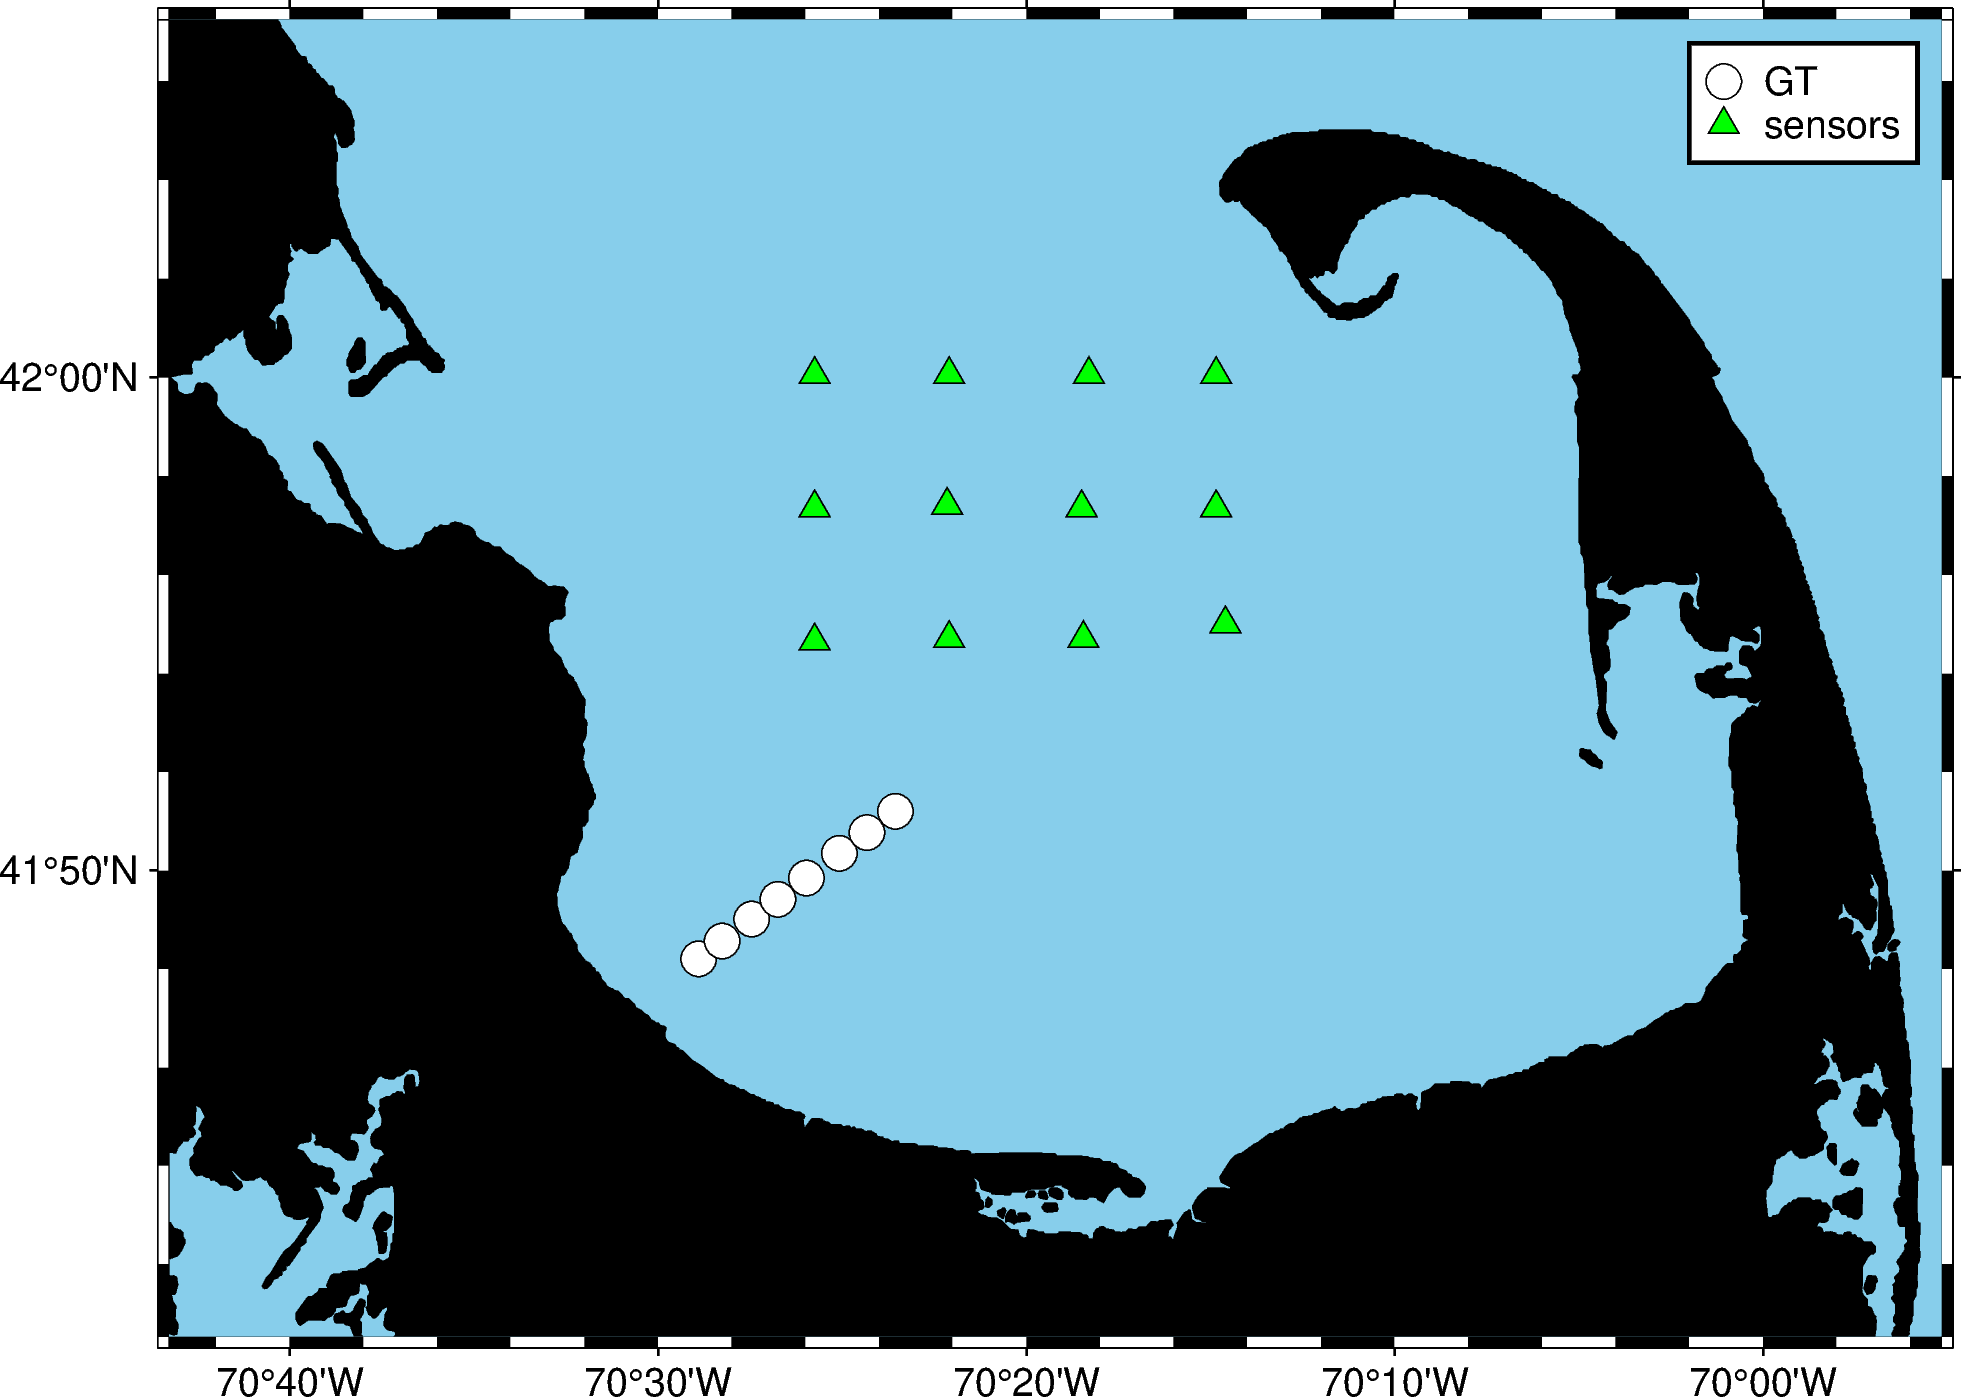

In [60]:
plot_localization(source_locs, title='Whale Trajectory', trajectory=True)

perform localization

In [61]:
# instantiate localizer
l = Localizer(k=4, multilat=MultilaterationOpt(method_thresh=float('inf')), consistency_thresh=1000, prune=False)

for i, measurement_set in enumerate(tqdm(measurements_list)):
    
    # build hypergraph
    success = l.set_measurements(measurement_set)
    
    # skip if not successful
    if not success:
        continue
    
    # associate and localize
    assoc, locs_est = l.associate_and_localize(method='partition', reduce_dups=False, last_step=False)
    
    if i == 0:
        locs_ests = locs_est
    else:
        locs_ests = np.append(locs_ests, locs_est, axis=0)
    
    l.reset()
    
locs_ests = np.asarray(locs_ests)

  0%|          | 0/4 [00:00<?, ?it/s]

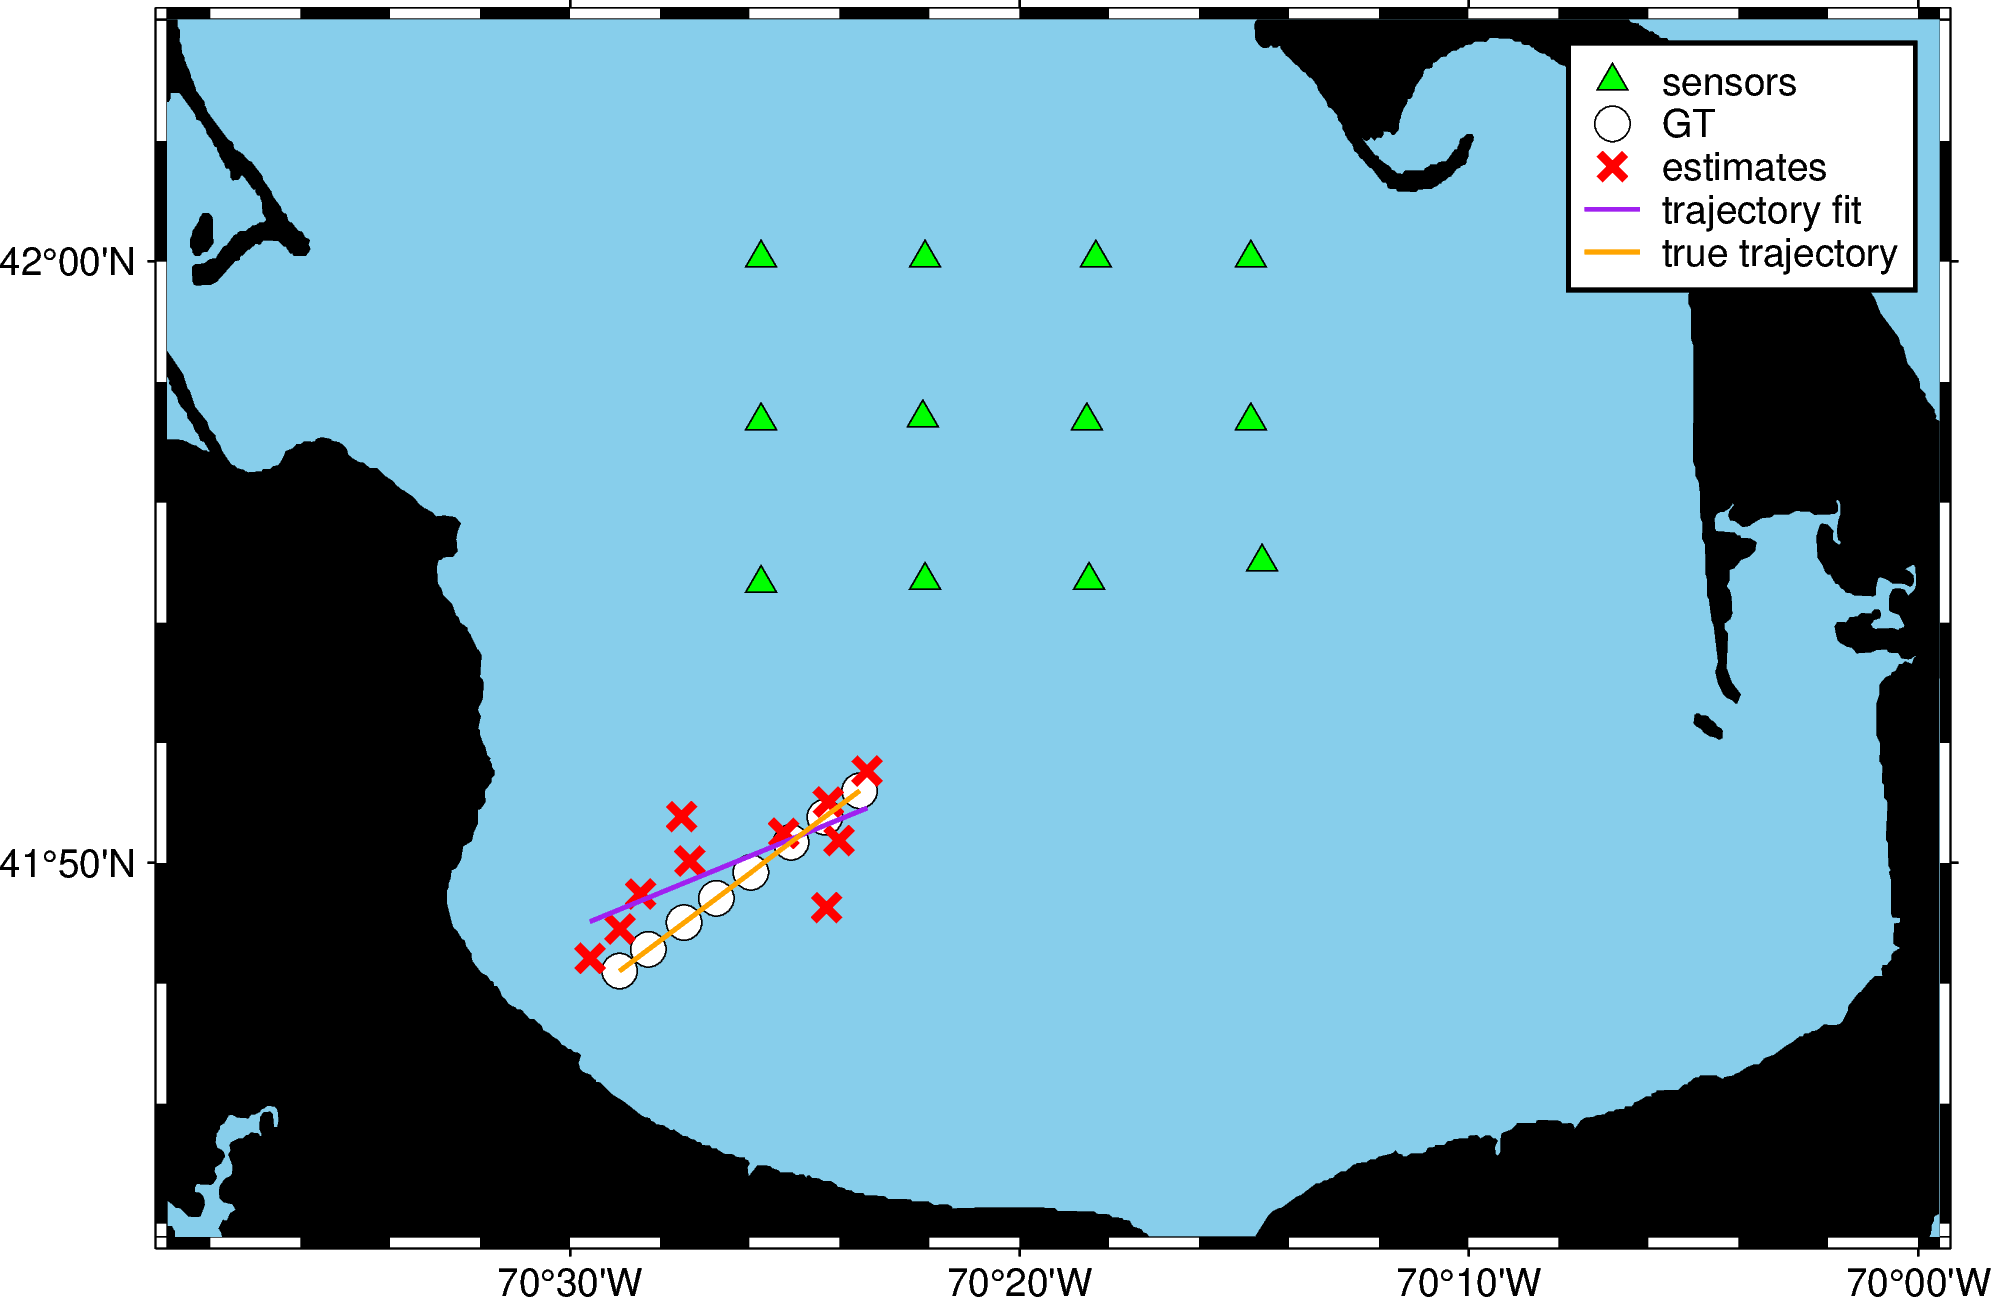

In [79]:
plot_localization(source_locs, locs_ests, title='Estimated Trajectory', trajectory=True, buffer=4)